# Assignmen 2
## Use of Callbacks

### CIFAR10

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
import torchvision
#from matplotlib.cbook import flatten

In [7]:
#import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpu = tf.config.list_physical_devices('GPU')[0]
print(tf.config.experimental.get_device_details(gpu))
gpus = tf.config.list_physical_devices('GPU')
[tf.config.experimental.set_memory_growth(gpu, True) for gpu in gpus]
print('Memory growth enabled')
print(tf.reduce_sum(tf.random.normal([1000, 1000])))

Num GPUs Available:  1
{'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 6GB Laptop GPU'}
Memory growth enabled
tf.Tensor(681.0791, shape=(), dtype=float32)


In [10]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)


/mnt/d/College/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [11]:
X_train = train_dataset.data
Y_train = np.array(train_dataset.targets)
x_test = test_dataset.data
y_test = np.array(test_dataset.targets)

In [12]:
X_train.shape, x_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [13]:
X_train, x_test= X_train/255.0, x_test/255.0

In [14]:
np.unique(Y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

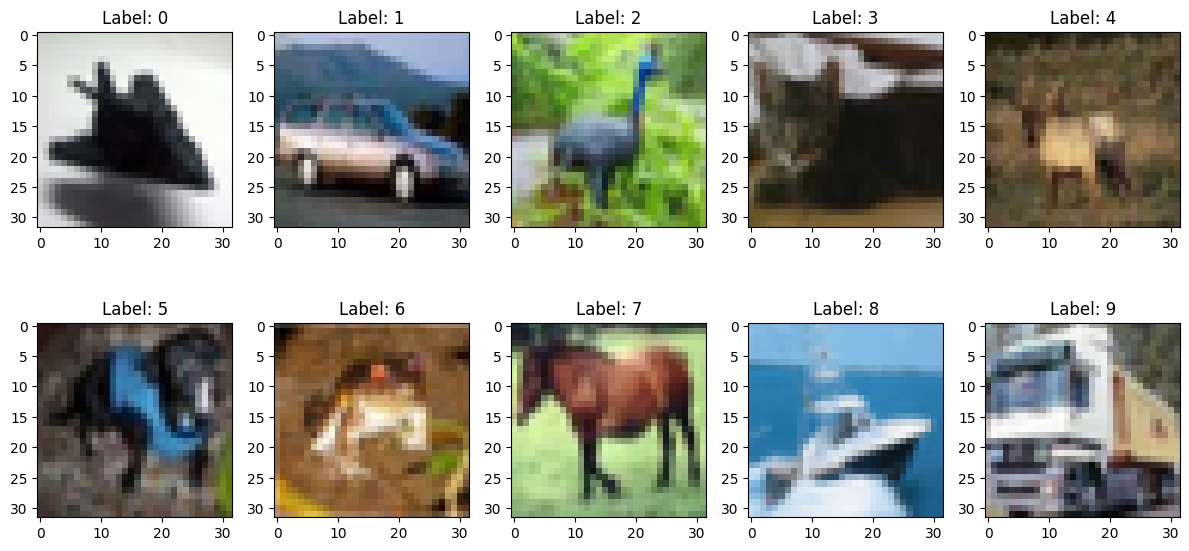

In [15]:
unique_labels = np.unique(Y_train)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, label in enumerate(unique_labels):
    idx = np.where(Y_train == label)[0][0]
    ax = axes[i]
    ax.imshow(X_train[idx])
    ax.set_title(f"Label: {label}")

plt.tight_layout()
plt.show()

In [41]:
model1= Sequential([
    Input(shape=X_train.shape[1:]),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

In [42]:
model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,354 (724.04 KB)

 Trainable params: 185,354 (724.04 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [45]:
es1 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=True)
cp1 = ModelCheckpoint("best_model1.keras", monitor='val_loss', save_best_only=True, verbose=1)

In [46]:
history = model1.fit(X_train, Y_train, epochs=500, validation_split=0.2, callbacks=[es1, cp1], verbose=1)

Epoch 1/500


2026-01-18 06:06:17.898859: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-18 06:06:17.898911: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-18 06:06:17.898922: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-18 06:06:18.489880: I external/l

1240/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1943 - loss: 2.1029
Epoch 1: val_loss improved from None to 1.90352, saving model to best_model1.keras

Epoch 1: finished saving model to best_model1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.2350 - loss: 2.0119 - val_accuracy: 0.2801 - val_loss: 1.9035
Epoch 2/500
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2888 - loss: 1.8817
Epoch 2: val_loss improved from 1.90352 to 1.84307, saving model to best_model1.keras

Epoch 2: finished saving model to best_model1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3047 - loss: 1.8653 - val_accuracy: 0.3244 - val_loss: 1.8431
Epoch 3/500
1240/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3379 - loss: 1.8201
Epoch 3: val_loss improved from 1.84307 to 1.81336, saving model to best_model1.keras

Epoch 3: finished saving model to best_model1.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3411 - loss: 1.8078 - val_accuracy:

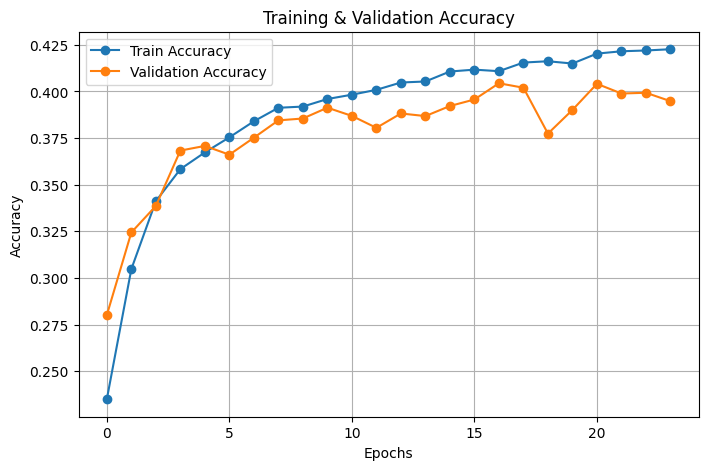

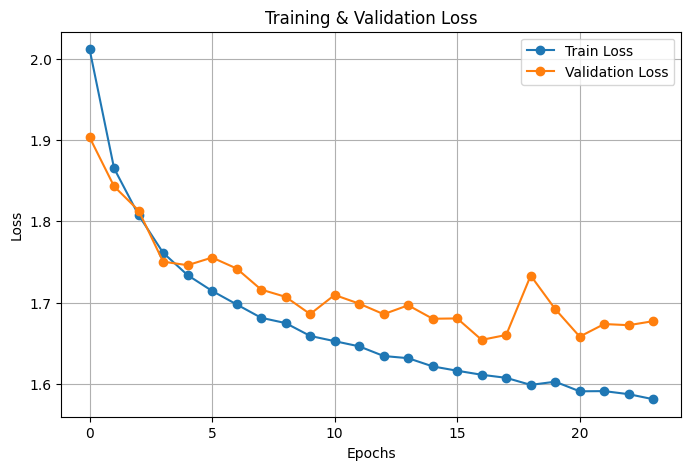

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [48]:
model1 = load_model("best_model1.keras")
test_loss, test_acc = model1.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4123 - loss: 1.6368
Test accuracy: 0.4123


### CIFAR100

In [49]:
(X_train1, Y_train1), (x_test1, y_test1) = tf.keras.datasets.cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 52s 0us/step


/mnt/d/College/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [50]:
X_train1, x_test1= X_train1/255.0, x_test1/255.0

In [51]:
np.unique(Y_train1)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [52]:
print(np.any(np.isnan(y_test1)))

False


In [53]:
X_train1.shape, x_test1.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

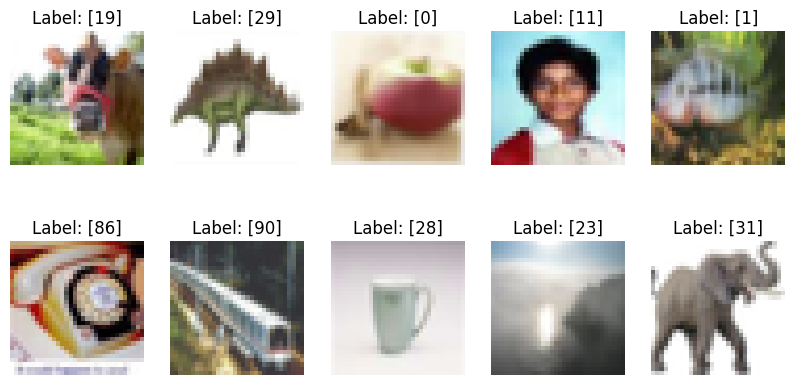

In [55]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train1[i])
    ax.set_title(f"Label: {Y_train1[i]}")
    ax.axis('off')
plt.show()

In [77]:
# MLP
model_100= Sequential([
    Input(shape=X_train1.shape[1:]),
    Flatten(),
    Dense(128, activation='selu'),
    Dense(256, activation='selu'),
    Dense(256, activation='selu'),
    Dense(128, activation='selu'),
    Dense(64, activation='selu'),
    Dense(100, activation='softmax')
])

In [78]:
model_100.compile(optimizer='RMSProp', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [79]:
model_100.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,812 (2.06 MB)

 Trainable params: 539,812 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
es2 = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=True)
#cp2 = ModelCheckpoint("model_epoch_{epoch:02d}.keras", save_freq='epoch', verbose=True)
cp2 = ModelCheckpoint("best_model2.keras", monitor='val_loss', save_best_only=True, verbose=1)
history_100 = model_100.fit(X_train1, Y_train1, epochs=500, validation_split=0.2, callbacks=[es2, cp2], verbose=1)

Epoch 1/500


2026-01-18 06:46:32.265635: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-18 06:46:32.903000: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_371', 520 bytes spill stores, 520 bytes spill loads



1238/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0282 - loss: 4.7003
Epoch 1: val_loss improved from None to 4.03324, saving model to best_model2.keras

Epoch 1: finished saving model to best_model2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.0454 - loss: 4.3935 - val_accuracy: 0.0845 - val_loss: 4.0332
Epoch 2/500
1233/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0883 - loss: 4.0046
Epoch 2: val_loss improved from 4.03324 to 3.83697, saving model to best_model2.keras

Epoch 2: finished saving model to best_model2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0943 - loss: 3.9628 - val_accuracy: 0.1105 - val_loss: 3.8370
Epoch 3/500
1240/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1171 - loss: 3.8163
Epoch 3: val_loss improved from 3.83697 to 3.81190, saving model to best_model2.keras

Epoch 3: finished saving model to best_model2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1196 - loss: 3.7902 - val_accuracy:

<Sequential name=sequential_4, built=True>

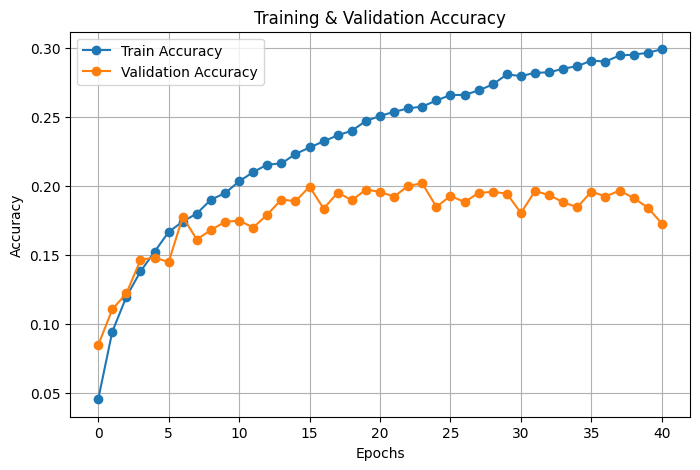

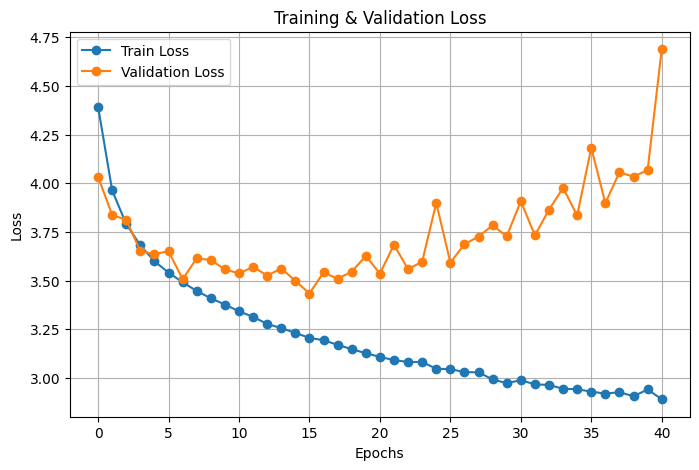

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(history_100.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_100.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_100.history['loss'], label='Train Loss', marker='o')
plt.plot(history_100.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [82]:
best_model_100 = load_model("best_model2.keras")

In [83]:
test_loss, test_acc = best_model_100.evaluate(x_test1, y_test1)
print(f"Test accuracy of the best model: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2036 - loss: 3.4603
Test accuracy of the best model: 0.2036


### VGG-16 Tuning

In [54]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam, RMSprop

In [ ]:
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation='selu'),
    Dense(128, activation='selu'),
    Dense(64, activation='selu'),
    Dense(100, activation='softmax'),
])

vgg_base.trainable = False
es1 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=True)
cp1 = ModelCheckpoint("best_model_vgg16.keras", monitor='val_loss', save_best_only=True, verbose=1)
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train1, Y_train1, epochs=100, callbacks=[es1, cp1], verbose=1)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1665 - loss: 3.5924

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.1666 - loss: 3.5922
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2940 - loss: 2.8212
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3187 - loss: 2.6857
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3423 - loss: 2.5800
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3500 - loss: 2.5343
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3696 - loss: 2.4429
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3745 - loss: 2.4216
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3808 - loss: 2.3871
Epoch 9/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3929 - loss: 2.3233
Epoch 10/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4059 - loss: 2.2747
Epoch 11/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4116 - loss: 2.2360
Epoch 12/100
1563/15